# Task 3: Real-Time Echocardiogram Video Analysis

Goal: build a real-time OpenCV pipeline that reads each frame of an ultrasound `.mp4`, applies mathematical enhancements, and displays the corrected feed live next to the raw feed.

**Per-frame pipeline:** Histogram Equalization → COLORMAP_JET → Color Balance → Log Transform → Power-Law (Gamma)

## 0. Setup & Configuration

In [1]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------ PLACEHOLDERS: EDIT THESE ------------------
VIDEO_PATH  = Path.cwd() / "data" / "VIDEO.mp4"   # <-- input ultrasound video
OUTPUT_PATH = Path.cwd() / "output" / "enhanced_echo.mp4"  # <-- used only if SAVE_OUTPUT = True
SAVE_OUTPUT = True                             
# --------------------------------------------------------------

# Tunable parameters
GAMMA          = 1.8      # > 1 darkens bright pixels -> suppresses white backscatter
BALANCE_SMOOTH = 0.9      # 0 = per-frame gray-world, closer to 1 = steadier gains (less flicker)
LOOP_VIDEO     = False    # restart the video when it ends
DISPLAY_WIDTH  = 480      # width of each panel in the monitoring window
USE_CV_WINDOW  = True     # True: cv2.imshow window | False: inline notebook display (no GUI needed)

## 1. Enhancement Functions

Each step is a standalone function so it can be tested on a single frame first.
The log and gamma transforms use 256-entry lookup tables (`cv2.LUT`), which is much faster than per-frame float math and suits real-time use.

| Step | Math |
|---|---|
| Histogram equalization | $s_k = \text{round}\left(\frac{CDF(r_k)-CDF_{min}}{N-CDF_{min}}\times 255\right)$ |
| Color balance (gray-world) | $C'_c = \text{clip}(g_c C_c)$, $g_c = \mu_{gray}/\mu_c$ |
| Log transform | $s = c\log(1+r)$, $c = 255/\log(256)$ |
| Power law | $s = 255\,(r/255)^{\gamma}$ |

In [2]:
# ---- Lookup tables (built once) ----
_r = np.arange(256, dtype=np.float32)
LOG_LUT = (255.0 / np.log(256.0) * np.log1p(_r)).clip(0, 255).astype(np.uint8)

def make_gamma_lut(gamma):
    return (255.0 * np.power(_r / 255.0, gamma)).clip(0, 255).astype(np.uint8)

GAMMA_LUT = make_gamma_lut(GAMMA)


def to_gray(frame_bgr):
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

def equalize(gray):
    return cv2.equalizeHist(gray)

def heatmap(gray):
    return cv2.applyColorMap(gray, cv2.COLORMAP_JET)

class ColorBalancer:
    """Gray-world balance with exponential smoothing of gains across frames."""
    def __init__(self, smooth=0.9):
        self.smooth = smooth
        self.gains = None

    def __call__(self, img_bgr):
        means = img_bgr.reshape(-1, 3).mean(axis=0) + 1e-6      # [B, G, R]
        new_gains = means.mean() / means
        self.gains = new_gains if self.gains is None else (
            self.smooth * self.gains + (1 - self.smooth) * new_gains)
        return np.clip(img_bgr.astype(np.float32) * self.gains, 0, 255).astype(np.uint8)

def log_transform(img):
    return cv2.LUT(img, LOG_LUT)

def power_law(img):
    return cv2.LUT(img, GAMMA_LUT)


def enhance_frame(frame_bgr, balancer):
    """Full pipeline for one frame. Returns dict of intermediate stages."""
    gray     = to_gray(frame_bgr)
    eq       = equalize(gray)
    jet      = heatmap(eq)
    balanced = balancer(jet)
    logged   = log_transform(balanced)
    final    = power_law(logged)
    return {"gray": gray, "equalized": eq, "jet": jet,
            "balanced": balanced, "log": logged, "final": final}

## 2. Sanity Check on a Single Frame

Before running the live loop, verify each stage on one frame.

Resolution: 112x112 | FPS: 50.0 | Frames: 174


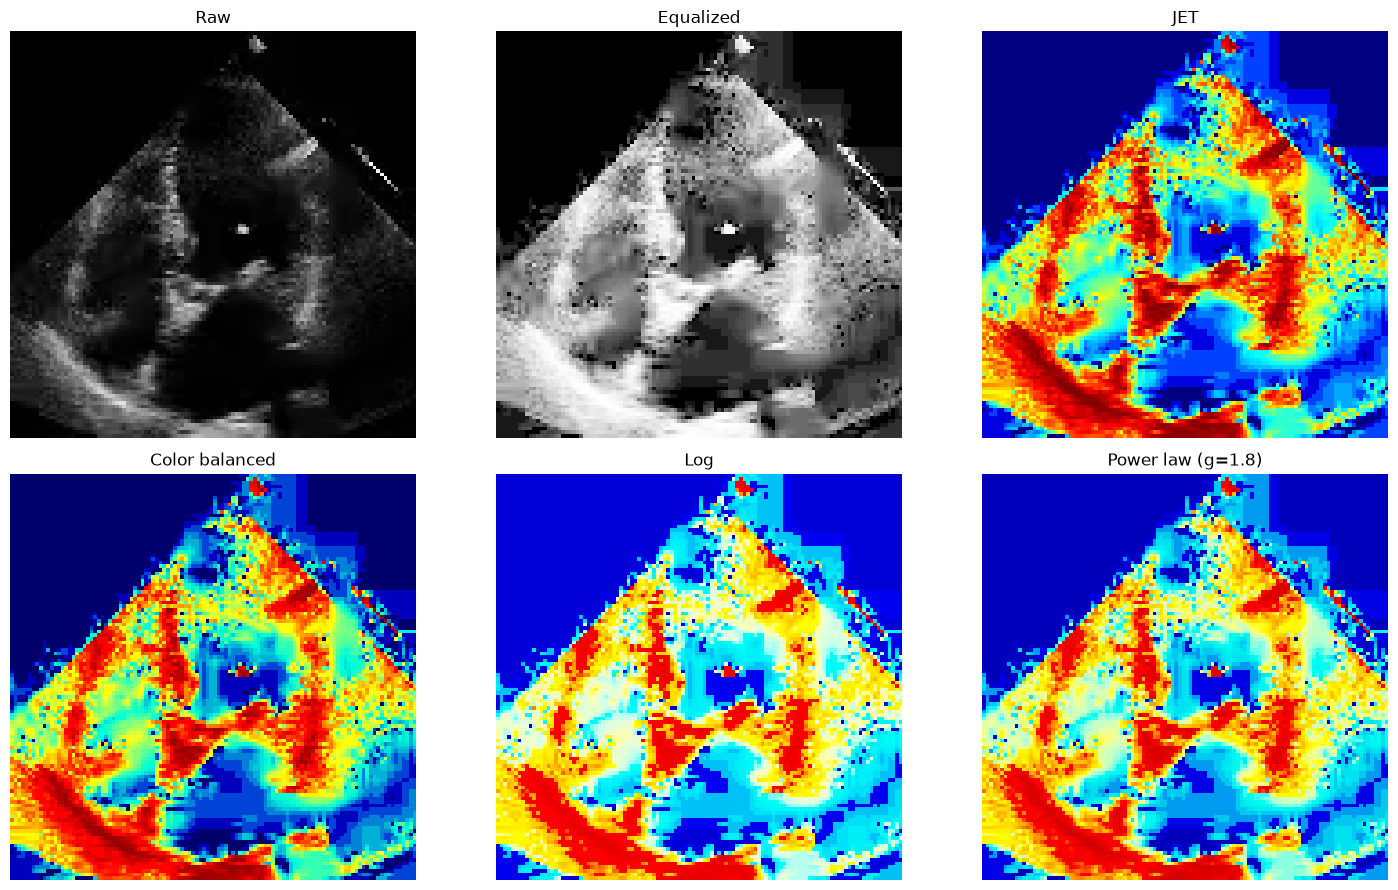

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Could not open video: {VIDEO_PATH}. Update VIDEO_PATH.")

fps    = cap.get(cv2.CAP_PROP_FPS) or 25
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Resolution: {width}x{height} | FPS: {fps:.1f} | Frames: {total}")

ok, test_frame = cap.read()
cap.release()
assert ok, "Could not read a frame from the video."

stages = enhance_frame(test_frame, ColorBalancer(BALANCE_SMOOTH))
titles = ["Raw", "Equalized", "JET", "Color balanced", "Log", f"Power law (g={GAMMA})"]
images = [stages["gray"], stages["equalized"], stages["jet"],
          stages["balanced"], stages["log"], stages["final"]]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for a, im, t in zip(axes.ravel(), images, titles):
    if im.ndim == 2:
        a.imshow(im, cmap="gray", vmin=0, vmax=255)
    else:
        a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

**Observation:** The log stage lifts the darker chamber interiors and low-intensity tissue, making faint internal boundaries more visible than in the raw frame. It also raises dark speckle and background energy. The subsequent power-law stage with `GAMMA=1.8` suppresses the brightest backscatter and restores separation in saturated regions, so the final view is less dominated by white echoes while retaining the main chamber and wall structure.

## 3. Real-Time Video Processing Loop & Monitoring Array

Reads frames in a `while` loop, enhances each one, and concatenates the raw and enhanced frames side by side.

- Press **q** (or **Esc**) in the video window to quit.
- If `cv2.imshow` doesn't work in your environment (remote/headless Jupyter), set `USE_CV_WINDOW = False` to display inline instead.

In [4]:
from IPython.display import display, clear_output
from PIL import Image

def label(img, text):
    out = img.copy()
    cv2.putText(out, text, (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 3, cv2.LINE_AA)
    cv2.putText(out, text, (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 1, cv2.LINE_AA)
    return out

def resize_to_width(img, w):
    h = int(img.shape[0] * w / img.shape[1])
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)

def build_monitor(raw_bgr, final_bgr):
    # Concatenate raw (unedited) and enhanced frames side by side.
    left  = label(resize_to_width(raw_bgr, DISPLAY_WIDTH), "RAW")
    right = label(resize_to_width(final_bgr, DISPLAY_WIDTH), "ENHANCED")
    return np.hstack([left, right])


def run_pipeline():
    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {VIDEO_PATH}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    frame_delay = 1.0 / fps
    balancer = ColorBalancer(BALANCE_SMOOTH)
    writer = None
    frame_count, t_start = 0, time.time()

    try:
        while True:
            t0 = time.time()
            ok, frame = cap.read()
            if not ok:
                if LOOP_VIDEO:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                    balancer = ColorBalancer(BALANCE_SMOOTH)
                    continue
                break

            result  = enhance_frame(frame, balancer)
            monitor = build_monitor(frame, result["final"])

            if SAVE_OUTPUT:
                if writer is None:
                    h, w = monitor.shape[:2]
                    writer = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
                writer.write(monitor)

            if USE_CV_WINDOW:
                cv2.imshow("Echocardiogram: RAW (left) vs ENHANCED (right) | q to quit", monitor)
                # waitKey also paces playback to the video's native FPS
                elapsed_ms = int((time.time() - t0) * 1000)
                key = cv2.waitKey(max(1, int(frame_delay * 1000) - elapsed_ms)) & 0xFF
                if key in (ord("q"), 27):
                    break
            else:
                clear_output(wait=True)
                display(Image.fromarray(cv2.cvtColor(monitor, cv2.COLOR_BGR2RGB)))
                time.sleep(max(0, frame_delay - (time.time() - t0)))

            frame_count += 1
    finally:
        cap.release()
        if writer is not None:
            writer.release()
        if USE_CV_WINDOW:
            cv2.destroyAllWindows()
            cv2.waitKey(1)   # helps the window close on macOS/Jupyter

    dt = time.time() - t_start
    print(f"Processed {frame_count} frames in {dt:.1f}s ({frame_count / max(dt, 1e-6):.1f} FPS)")

run_pipeline()

Processed 174 frames in 6.6s (26.3 FPS)


## 4. Processing-Speed Benchmark (Optional)

Checks whether the pipeline keeps up in real time, without display overhead.

In [5]:
cap = cv2.VideoCapture(VIDEO_PATH)
balancer = ColorBalancer(BALANCE_SMOOTH)
n, t0 = 0, time.time()
while n < 200:
    ok, frame = cap.read()
    if not ok:
        break
    enhance_frame(frame, balancer)
    n += 1
cap.release()
dt = time.time() - t0
print(f"Pipeline throughput: {n / dt:.1f} FPS over {n} frames "
      f"({1000 * dt / max(n, 1):.2f} ms/frame)")

Pipeline throughput: 536.2 FPS over 174 frames (1.87 ms/frame)


## 5. Notes & Conclusions

- **Why gamma > 1 here:** unlike the chest X-ray task (γ < 1 to lift midtones), the goal is to *suppress* blinding white backscatter, so γ > 1 compresses the bright end.
- **Why the log step comes before gamma:** the log lifts the dark chamber interiors and the gamma then pulls the bright noise back down.
- **Color balance smoothing:** per-frame gray-world gains can flicker as the heart moves; smoothing the gains over time keeps the color stable.

The largest perceptual improvement comes from histogram equalization followed by the log transform: equalization expands the available contrast, while the log stage reveals darker chamber interiors and subtle tissue echoes. JET mapping and gray-world balancing make intensity changes easier to inspect as color transitions, but they do not add anatomical information. The final gamma stage is important for controlling bright backscatter; `GAMMA=1.8` provides a useful compromise for this footage, while larger values would risk suppressing genuine bright structures. `BALANCE_SMOOTH=0.9` keeps the color stable across frames and reduces flicker, although a lower value would react faster to abrupt illumination changes. The pipeline processed all 174 frames at 26.3 FPS with display and video writing enabled, while the enhancement computation alone reached 536.2 FPS (1.87 ms/frame), indicating that the mathematical pipeline is fast enough for real-time use and that display/output overhead is the main performance cost. The enhanced stream should be used as a complementary view alongside the raw feed, not as a diagnostic substitute.